## Lucas-Kanade (Sparse) + Farnebäck (Dense)

---

### What This Notebook Does
This notebook implements two classical optical flow methods on the KITTI dataset:
1. **Lucas-Kanade** : sparse flow (tracks specific keypoints)
2. **Farnebäck** : dense flow (estimates flow for every pixel)

### Key Concept Reminder
Optical flow answers: **"Where did each pixel move between two frames?"**
- Lucas-Kanade: tracks a FEW important points (sparse)
- Farnebäck: tracks EVERY pixel (dense)


In [16]:
from google.colab import drive
drive.mount('/content/drive')

# Verify KITTI DataSet
import os

KITTI_ROOT = '/content/drive/MyDrive/OpticalFlow/KITTI'

if os.path.exists(KITTI_ROOT):
    print('KITTI folder found at:', KITTI_ROOT)
    print('Contents:', os.listdir(KITTI_ROOT)[:10])
else:
    print('KITTI folder NOT found.')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
KITTI folder found at: /content/drive/MyDrive/OpticalFlow/KITTI
Contents: ['training']


In [17]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import glob
from pathlib import Path

%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['figure.dpi'] = 100

print(f"OpenCV version : {cv2.__version__}")
print(f"NumPy version  : {np.__version__}")

OpenCV version : 4.13.0
NumPy version  : 2.0.2


In [18]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/OpticalFlow/KITTI"):
    level = root.replace("/content/drive/MyDrive/OpticalFlow/KITTI", '').count(os.sep)
    indent = '   ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:3]:  # first 3 files per folder
        print(f"{indent}   {f}")

KITTI/
   training/
      image_1/
         000112_10.png
         000112_11.png
         000145_10.png
      disp_noc/
         000000_10.png
         000001_10.png
         000002_10.png
      calib/
         000003.txt
         000004.txt
         000005.txt
      colored_1/
         000109_10.png
         000050_10.png
         000083_10.png
      colored_0/
         000050_10.png
         000109_10.png
         000120_10.png
      disp_refl_noc/
         000125_10.png
         000037_10.png
         000103_10.png
      disp_occ/
         000000_10.png
         000001_10.png
         000002_10.png
      flow_occ/
         000000_10.png
         000001_10.png
         000002_10.png
      flow_noc/
         000000_10.png
         000001_10.png
         000002_10.png
      disp_refl_occ/
         000178_10.png
         000043_10.png
         000014_10.png
      image_0/
         000112_11.png
         000112_10.png
         000145_10.png


### What is KITTI?
KITTI is a real autonomous driving dataset captured from a car driving in Germany.
It contains:
- Pairs of consecutive frames (frame1, frame2)
- Ground truth optical flow (what the correct answer looks like)
- Real driving scenes : cars, pedestrians, roads


### Ground Truth Flow Format (Important!)
KITTI stores flow as special 16-bit PNG files.
The formula to decode: `flow = (pixel_value - 2^15) / 64.0`

In [19]:
# Configuration
KITTI_BASE = "/content/drive/MyDrive/OpticalFlow/KITTI"
IMAGE_DIR  = "/content/drive/MyDrive/OpticalFlow/KITTI/training/image_1"
COLOR_DIR  = "/content/drive/MyDrive/OpticalFlow/KITTI/training/colored_1"
FLOW_DIR   = "/content/drive/MyDrive/OpticalFlow/KITTI/training/flow_occ"

# Verify all exist
print(f"Image dir exists : {os.path.exists(IMAGE_DIR)}")
print(f"Color dir exists : {os.path.exists(COLOR_DIR)}")
print(f"Flow dir exists  : {os.path.exists(FLOW_DIR)}")

# Count available pairs
import glob
images = sorted(glob.glob(f"{IMAGE_DIR}/*_10.png"))
print(f"Frame pairs found: {len(images)}")

# Output directory inside Google Drive
OUTPUT_DIR = "/content/drive/MyDrive/OpticalFlow/results"
os.makedirs(f"{OUTPUT_DIR}/lucas_kanade", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/farneback", exist_ok=True)
print(f"\n Output directory created at: {OUTPUT_DIR}")

Image dir exists : True
Color dir exists : True
Flow dir exists  : True
Frame pairs found: 194

 Output directory created at: /content/drive/MyDrive/OpticalFlow/results


In [20]:
# HELPER FUNCTIONS

def load_image(path):
    """Load image from disk and return as RGB numpy array (H, W, 3)."""
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def load_kitti_flow(path):

    flow_raw = cv2.imread(path, cv2.IMREAD_ANYDEPTH | cv2.IMREAD_COLOR)
    if flow_raw is None:
        return None, None
    valid = flow_raw[:, :, 0] > 0 # B channel = validity mask
    u = (flow_raw[:, :, 2].astype(np.float32) - 2**15) / 64.0   # R channel = horizontal flow
    v = (flow_raw[:, :, 1].astype(np.float32) - 2**15) / 64.0   # G channel = vertical flow
    return np.stack([u, v], axis=2), valid


def get_image_pairs(image_dir, max_pairs=10):
    """
    Return list of (frame1_path, frame2_path) tuples from KITTI image directory.

    KITTI convention: 000000_10.png is frame 1, 000000_11.png is frame 2.
    """
    frame1_files = sorted(glob.glob(os.path.join(image_dir, "*_10.png")))

    pairs = []
    for f1_path in frame1_files[:max_pairs]:
        f2_path = f1_path.replace("_10.png", "_11.png")
        if os.path.exists(f2_path):
            pairs.append((f1_path, f2_path))

    print(f"Found {len(pairs)} image pairs")
    return pairs

Before computing anything, let's **see what KITTI looks like**.
This is EDA (Exploratory Data Analysis).

We'll see:
- Two consecutive frames from a driving car
- The difference between them (motion visible as brightness changes)

Found 10 image pairs
Image shape  : (370, 1226, 3)
Image dtype  : uint8
Pixel range  : [6, 255]
Flow shape   : (370, 1226, 2)
Valid pixels : 162583 / 453620


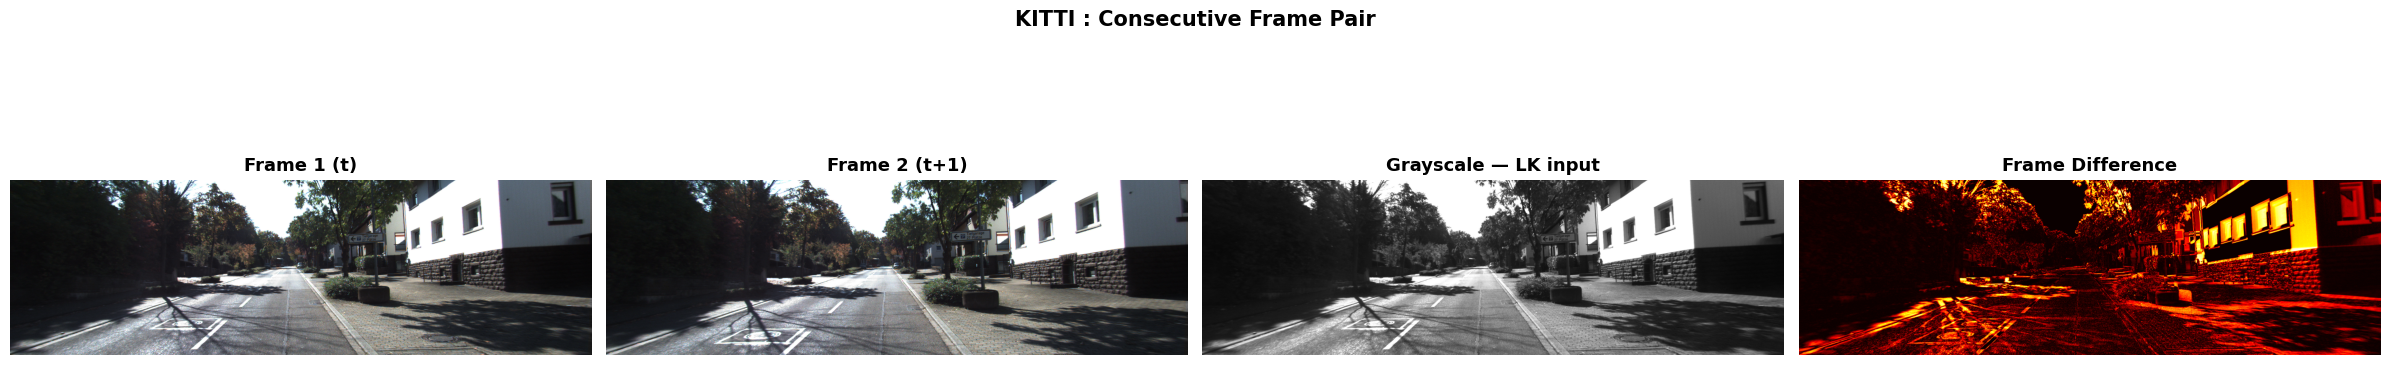

In [29]:
# DATASET EXPLORATION

if not IMAGE_DIR:
    raise RuntimeError("IMAGE_DIR not set : check configuration cell")

pairs = get_image_pairs(IMAGE_DIR, max_pairs=10)
if not pairs:
    raise RuntimeError(f"No image pairs found in {IMAGE_DIR}")

frame1_path, frame2_path = pairs[0]

# Grayscale frames for computation
frame1 = load_image(frame1_path)
frame2 = load_image(frame2_path)

# Color frames for visualization : raise error if colored_0 missing
color1_path = frame1_path.replace("image_1", "colored_1")
color2_path = frame2_path.replace("image_1", "colored_1")

if not os.path.exists(color1_path):
    raise RuntimeError(f"colored_1 folder not found: {color1_path}")

color1 = load_image(color1_path)
color2 = load_image(color2_path)

# Ground truth flow
flow_path = frame1_path.replace("image_1", "flow_occ")
if not os.path.exists(flow_path):
    raise RuntimeError(f"Ground truth flow not found: {flow_path}")

gt_flow, valid = load_kitti_flow(flow_path)

print(f"Image shape  : {frame1.shape}")
print(f"Image dtype  : {frame1.dtype}")
print(f"Pixel range  : [{frame1.min()}, {frame1.max()}]")
print(f"Flow shape   : {gt_flow.shape}")
print(f"Valid pixels : {valid.sum()} / {valid.size}")

# float32 prevents uint8 wrap-around during subtraction
diff = np.abs(frame1.astype(np.float32) - frame2.astype(np.float32))
diff_normalized = (diff / diff.max() * 255).astype(np.uint8)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].imshow(color1)
axes[0].set_title("Frame 1 (t)", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(color2)
axes[1].set_title("Frame 2 (t+1)", fontsize=13, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(frame1, cmap='gray')
axes[2].set_title("Grayscale — LK input", fontsize=13, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(diff_normalized.mean(axis=2), cmap='hot')
axes[3].set_title("Frame Difference", fontsize=13, fontweight='bold')
axes[3].axis('off')

plt.suptitle("KITTI : Consecutive Frame Pair", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/00_dataset_exploration.png", bbox_inches='tight', dpi=150)
plt.show()


#Lucas-Kanade Sparse Optical Flow

Lucas-Kanade works in 3 steps:
1. **Find keypoints** : corners and edges where motion is detectable (using Shi-Tomasi)
2. **Track each keypoint** : using the constraint: `Ix*u + Iy*v = -It`
3. **Draw arrows** : showing where each point moved

### Why Only Track Corners?
The **aperture problem** means flat regions are ambiguous; you can't tell which direction they moved. Corners have unique motion signatures.

### Key Parameters
- `maxCorners=500` : how many keypoints to track
- `winSize=(15,15)` : window size for local estimation
- `maxLevel=3` : pyramid levels for large motion

In [22]:
# LUCAS-KANADE IMPLEMENTATION

def compute_lucas_kanade(frame1, frame2, max_corners=500, quality=0.3,
                          min_distance=7, win_size=15, max_level=3):

    # LK operates on intensity gradients (Ix, Iy, It) : color is irrelevant
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

    # Shi-Tomasi: keeps corners where min(λ1, λ2) exceeds quality threshold
    p0 = cv2.goodFeaturesToTrack(
        gray1,
        maxCorners=max_corners,
        qualityLevel=quality,
        minDistance=min_distance,
        blockSize=7
    )

    if p0 is None or len(p0) == 0:
        print("No keypoints detected — try lowering qualityLevel")
        return None, None, None, None, None

    print(f"Detected {len(p0)} keypoints in frame 1")

    # Pyramid levels handle large displacements : 16px at level 0 becomes 1px at level 4
    # Stop when correction < 0.01px (converged) or after 30 iterations
    lk_params = dict(
        winSize=(win_size, win_size),
        maxLevel=max_level,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
    )

    # status: 1 = tracked successfully, 0 = failed (occlusion, left frame, flat region)
    p1, status, _ = cv2.calcOpticalFlowPyrLK(gray1, gray2, p0, None, **lk_params)

    good_new = p1[status == 1]
    good_old = p0[status == 1]

    print(f"Successfully tracked {len(good_new)}/{len(p0)} points")

    return p0, p1, good_old, good_new, status


def visualize_lucas_kanade(frame1, frame2, good_old, good_new, title="Lucas-Kanade Flow"):
    #Visualize LK tracking : green=origin, red=destination, yellow=motion vector.
    vis = frame2.copy()

    for old, new in zip(good_old, good_new):
        # ravel() flattens [[x,y]] → [x,y]; int() required by OpenCV drawing functions
        old_pt = tuple(old.ravel().astype(int))
        new_pt = tuple(new.ravel().astype(int))

        cv2.arrowedLine(vis, old_pt, new_pt, color=(255, 200, 0), thickness=2, tipLength=0.3)
        cv2.circle(vis, old_pt, radius=3, color=(0, 255, 0), thickness=-1)
        cv2.circle(vis, new_pt, radius=3, color=(255, 0, 0), thickness=-1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(frame1)
    axes[0].set_title("Frame 1 (t)", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(frame2)
    axes[1].set_title("Frame 2 (t+1)", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(vis)
    axes[2].set_title("Lucas-Kanade Flow\n(Green=origin, Red=destination, Yellow=motion)",
                      fontsize=11, fontweight='bold')
    axes[2].axis('off')

    # mpatches needed because OpenCV drawings aren't matplotlib objects
    legend_elements = [
        mpatches.Patch(color='green',  label='Original position (frame 1)'),
        mpatches.Patch(color='red',    label='New position (frame 2)'),
        mpatches.Patch(color='yellow', label='Motion vector')
    ]
    axes[2].legend(handles=legend_elements, loc='lower right', fontsize=8)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig, vis


print("Lucas-Kanade functions defined")

Lucas-Kanade functions defined


Running Lucas-Kanade on KITTI dataset...

Pair 1/5: 000000_10.png
Detected 126 keypoints in frame 1
Successfully tracked 112/126 points


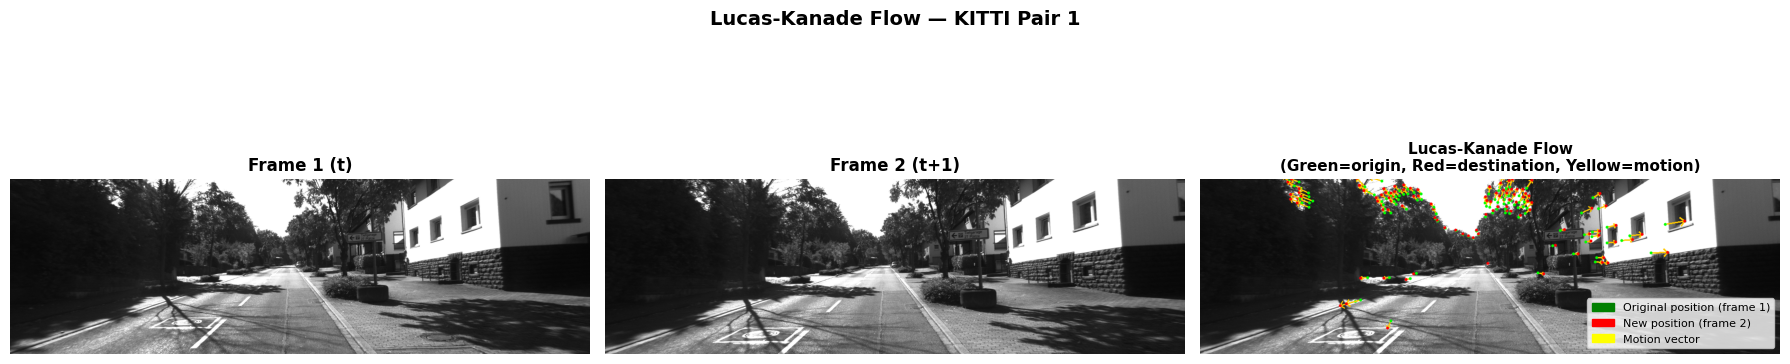

Mean motion magnitude : 14.02 pixels
Max motion magnitude  : 42.29 pixels

Pair 2/5: 000001_10.png
Detected 7 keypoints in frame 1
Successfully tracked 7/7 points


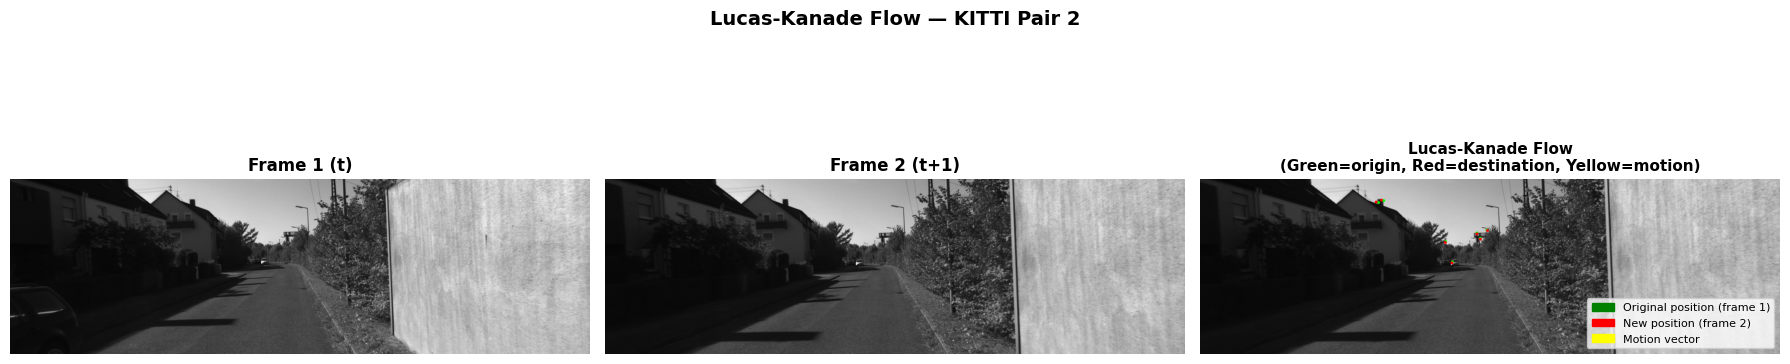

Mean motion magnitude : 2.94 pixels
Max motion magnitude  : 4.52 pixels

Pair 3/5: 000002_10.png
Detected 64 keypoints in frame 1
Successfully tracked 62/64 points


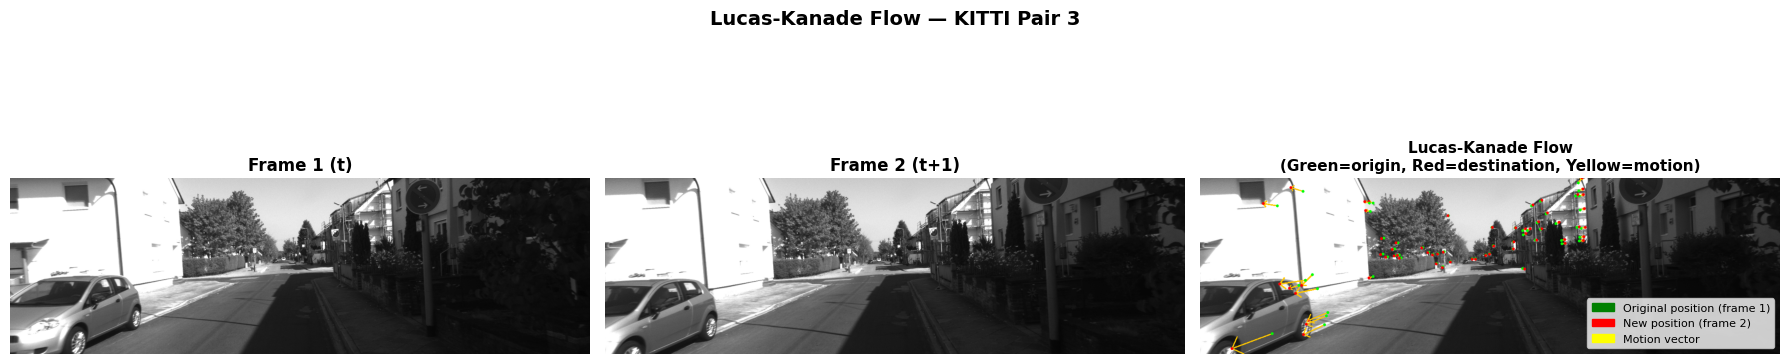

Mean motion magnitude : 11.38 pixels
Max motion magnitude  : 91.65 pixels

Pair 4/5: 000003_10.png
Detected 74 keypoints in frame 1
Successfully tracked 72/74 points


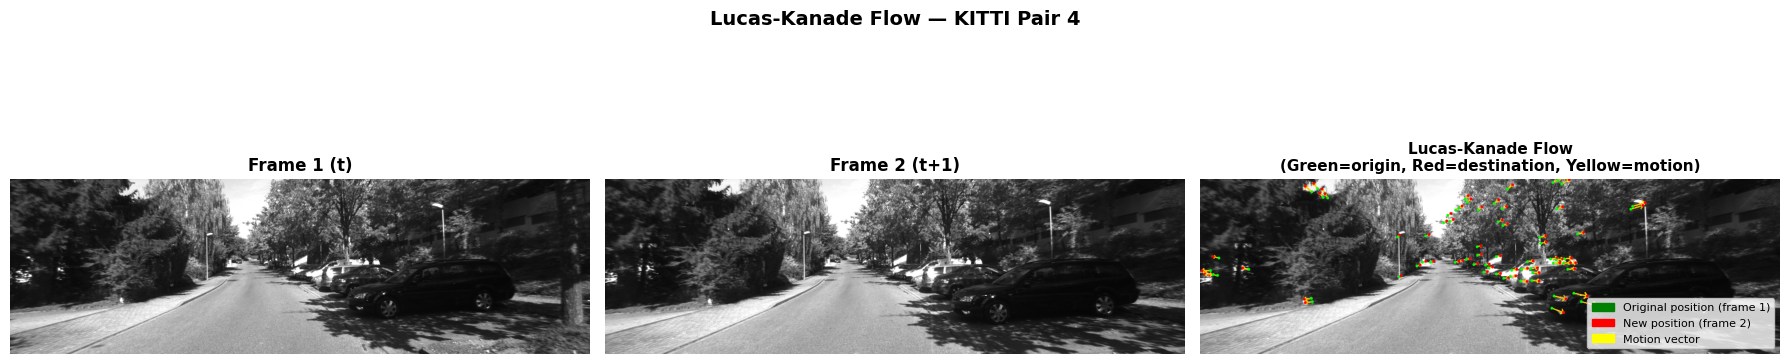

Mean motion magnitude : 13.41 pixels
Max motion magnitude  : 33.46 pixels

Pair 5/5: 000004_10.png
Detected 100 keypoints in frame 1
Successfully tracked 96/100 points


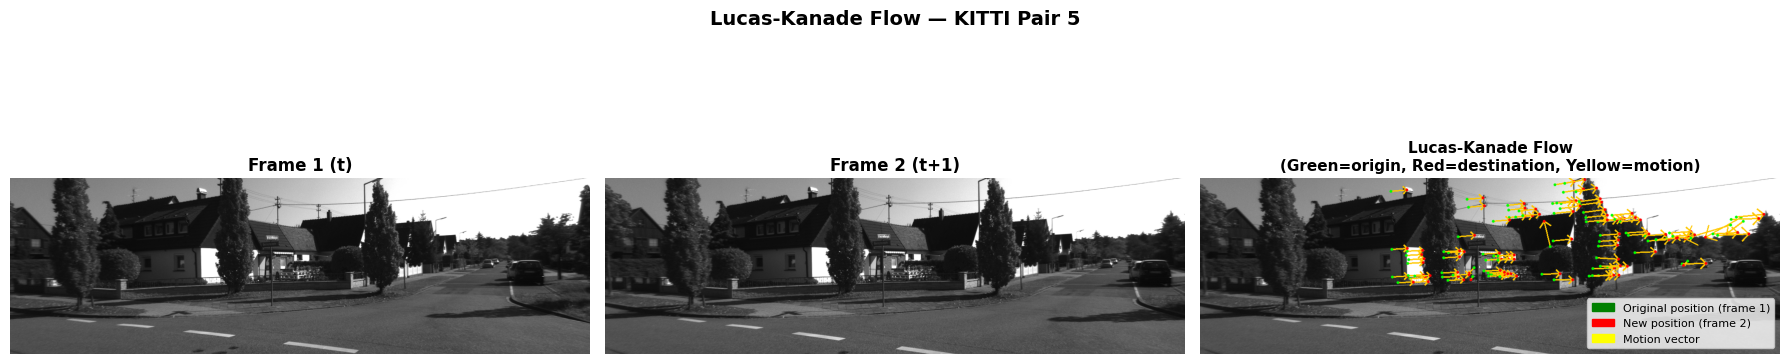

Mean motion magnitude : 40.80 pixels
Max motion magnitude  : 100.38 pixels

Lucas-Kanade complete


In [23]:
# RUN LUCAS-KANADE ON KITTI

print("Running Lucas-Kanade on KITTI dataset...")

lk_results = []

for i, (f1_path, f2_path) in enumerate(pairs[:5]):
    print(f"\nPair {i+1}/5: {os.path.basename(f1_path)}")

    frame1 = load_image(f1_path)
    frame2 = load_image(f2_path)

    p0, p1, good_old, good_new, status = compute_lucas_kanade(frame1, frame2)

    if good_old is None:
        continue

    fig, vis = visualize_lucas_kanade(
        frame1, frame2, good_old, good_new,
        title=f"Lucas-Kanade Flow — KITTI Pair {i+1}"
    )

    plt.savefig(f"{OUTPUT_DIR}/lucas_kanade/pair_{i+1:02d}.png", bbox_inches='tight', dpi=150)
    plt.show()

    # motion_vectors shape (N,2) — each row is (dx, dy) for one tracked point
    motion_vectors     = good_new - good_old
    motion_magnitudes  = np.sqrt(motion_vectors[:, 0]**2 + motion_vectors[:, 1]**2)

    lk_results.append({
        'pair_id'    : i + 1,
        'n_tracked'  : len(good_new),
        'mean_motion': motion_magnitudes.mean(),
        'max_motion' : motion_magnitudes.max(),
        'frame1_path': f1_path
    })

    print(f"Mean motion magnitude : {lk_results[-1]['mean_motion']:.2f} pixels")
    print(f"Max motion magnitude  : {lk_results[-1]['max_motion']:.2f} pixels")

print("\nLucas-Kanade complete")

## Step 5: Farnebäck Dense Optical Flow

### What Farnebäck Does (Chapter 4 Recap)

Unlike Lucas-Kanade which tracks specific points, Farnebäck estimates flow for **every single pixel**.

Key idea: Approximate the neighborhood of each pixel as a **polynomial**:
`I(x) ≈ xᵀAx + bᵀx + c`

Then find the displacement that best explains how the polynomial changed between frames.

### HSV Visualization
Dense flow has 2 values per pixel (u, v). We visualize it as a color:
- **Hue** (color) = flow direction (0°=right, 90°=down, 180°=left, 270°=up)
- **Saturation** (intensity) = flow magnitude (brighter = faster)
- **Value** = always 255 (full brightness)

This creates the beautiful colored flow maps you've seen in papers.

In [24]:
# FARNEBÄCK DENSE FLOW IMPLEMENTATION

def compute_farneback(frame1, frame2,
                       pyr_scale=0.5,   # How much to scale each pyramid level
                       levels=3,         # Number of pyramid levels
                       winsize=15,       # Window size for smoothing
                       iterations=3,    # Iterations per pyramid level
                       poly_n=5,        # Polynomial neighborhood size
                       poly_sigma=1.2): # Gaussian for polynomial smoothing

    # Convert to grayscale : same reason as LK, we work with intensity
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

    # Compute dense flow using OpenCV's Farnebäck implementation
    flow = cv2.calcOpticalFlowFarneback(
        gray1, gray2,
        None,          # No previous flow (start fresh)
        pyr_scale,     # Scale factor between pyramid levels
        levels,        # Number of pyramid levels
        winsize,       # Window for averaging flow
        iterations,    # Iterations at each level
        poly_n,        # Polynomial neighborhood
        poly_sigma,    # Gaussian std for polynomial
        0              # Flags (0 = default)
    )

    # flow has shape (H, W, 2)
    # flow[:,:,0] = horizontal displacement (u) in pixels
    # flow[:,:,1] = vertical displacement (v) in pixels

    return flow


def flow_to_hsv(flow):

    # Extract horizontal (u) and vertical (v) components
    u = flow[:, :, 0]  # Horizontal flow (positive = rightward)
    v = flow[:, :, 1]  # Vertical flow (positive = downward)

    # Compute flow magnitude at each pixel
    # magnitude = sqrt(u² + v²) : how fast is this pixel moving?
    magnitude = np.sqrt(u**2 + v**2)

    # Compute flow angle at each pixel
    # angle = arctan2(v, u) : which direction is this pixel moving?
    # arctan2 returns values in [-π, π], we convert to [0, 2π]
    angle = np.arctan2(v, u)  # In radians, range [-π, π]

    # Create HSV image (same size as flow)
    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)

    # HUE: Convert angle from radians to degrees (0-360), then to OpenCV range (0-180)
    # OpenCV uses 0-180 for hue (not 0-360) to fit in uint8
    hsv[:, :, 0] = ((angle + np.pi) / (2 * np.pi) * 180).astype(np.uint8)

    # SATURATION: Normalize magnitude to 0-255
    # Pixels with more motion get higher saturation (more vivid color)
    max_magnitude = magnitude.max()
    if max_magnitude > 0:  # Avoid division by zero
        hsv[:, :, 1] = (magnitude / max_magnitude * 255).astype(np.uint8)

    # VALUE: Always maximum brightness (255)
    hsv[:, :, 2] = 255

    # Convert HSV to RGB for display
    rgb_vis = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    return rgb_vis


def visualize_farneback(frame1, frame2, flow, title="Farnebäck Dense Flow"):

    # Convert flow to HSV visualization
    flow_hsv = flow_to_hsv(flow)

    # Compute magnitude for grayscale heatmap
    magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].imshow(frame1)
    axes[0].set_title("Frame 1 (t)", fontsize=11, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(frame2)
    axes[1].set_title("Frame 2 (t+1)", fontsize=11, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(flow_hsv)
    axes[2].set_title("HSV Flow\n(Color=Direction, Brightness=Speed)",
                      fontsize=10, fontweight='bold')
    axes[2].axis('off')

    # Magnitude heatmap : shows SPEED regardless of direction
    im = axes[3].imshow(magnitude, cmap='hot')  # hot colormap: black=slow, white=fast
    axes[3].set_title("Flow Magnitude\n(bright=fast motion)",
                      fontsize=10, fontweight='bold')
    axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04, label='pixels/frame')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

    return fig, flow_hsv


print("Farnebäck functions defined")

Farnebäck functions defined


Running Farnebäck Dense Flow on KITTI dataset...

Pair 1/5: 000000_10.png
Flow shape: (370, 1226, 2)
u range: [-74.59, 63.60] pixels
v range: [-61.79, 146.21] pixels


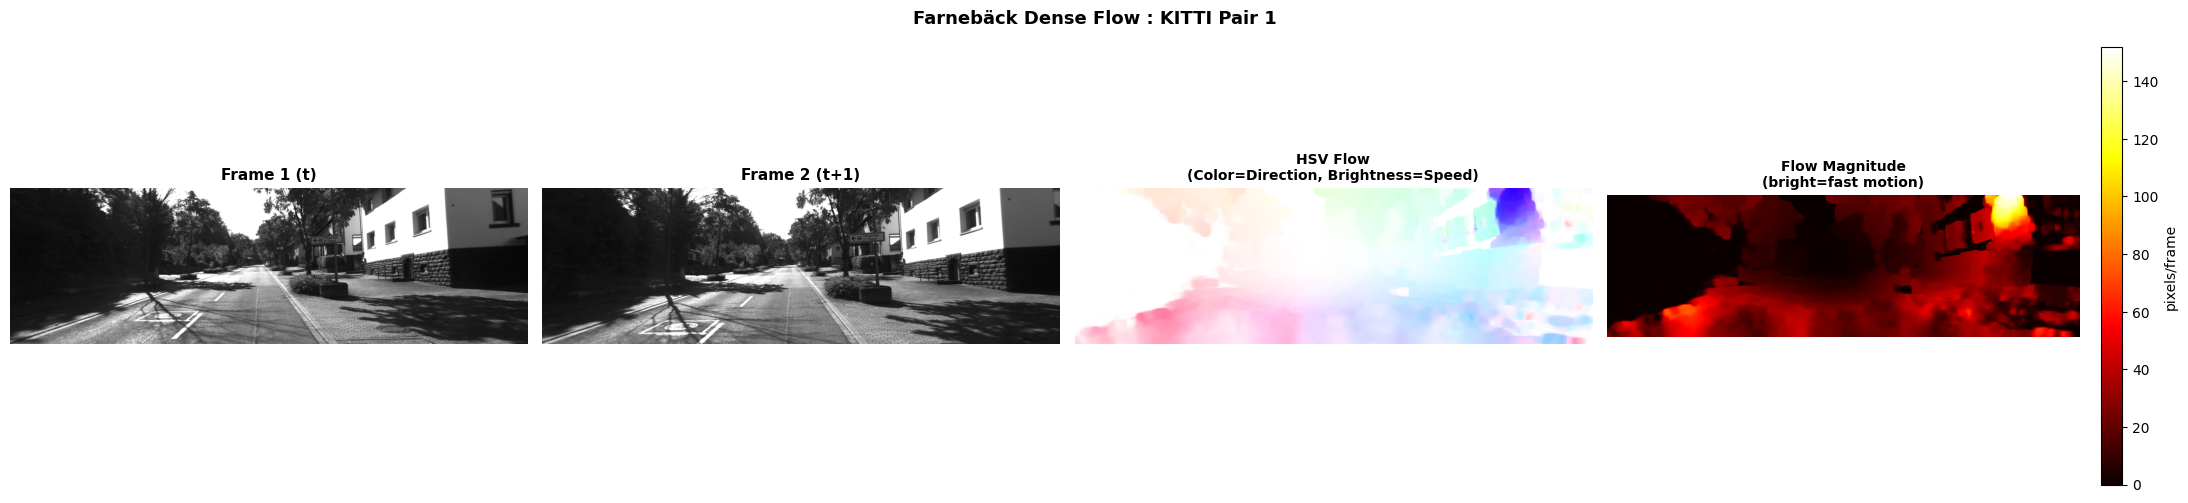

Mean magnitude: 17.092 px/frame

Pair 2/5: 000001_10.png
Flow shape: (370, 1226, 2)
u range: [-105.18, 107.26] pixels
v range: [-52.37, 29.05] pixels


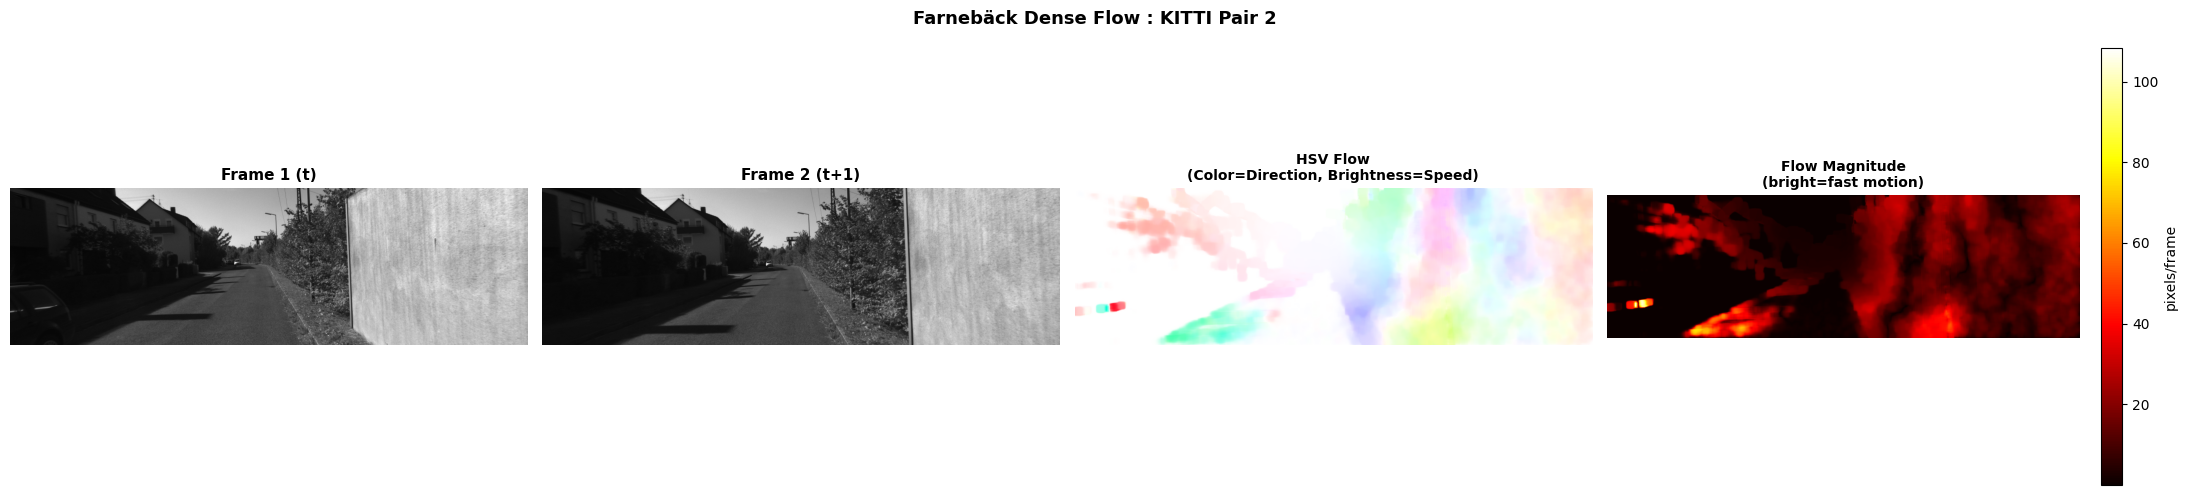

Mean magnitude: 10.141 px/frame

Pair 3/5: 000002_10.png
Flow shape: (376, 1241, 2)
u range: [-52.72, 33.21] pixels
v range: [-122.62, 177.90] pixels


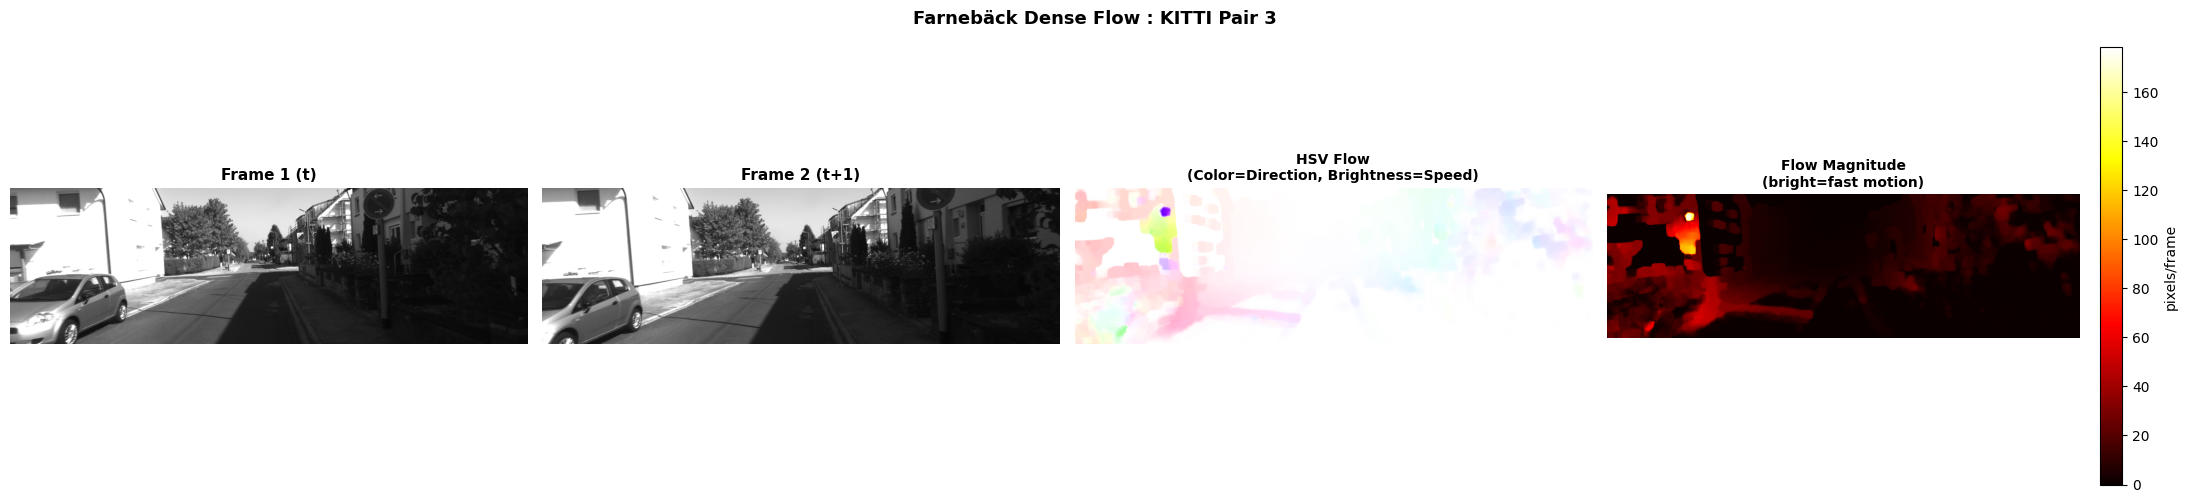

Mean magnitude: 8.426 px/frame

Pair 4/5: 000003_10.png
Flow shape: (375, 1242, 2)
u range: [-64.87, 54.79] pixels
v range: [-21.37, 26.63] pixels


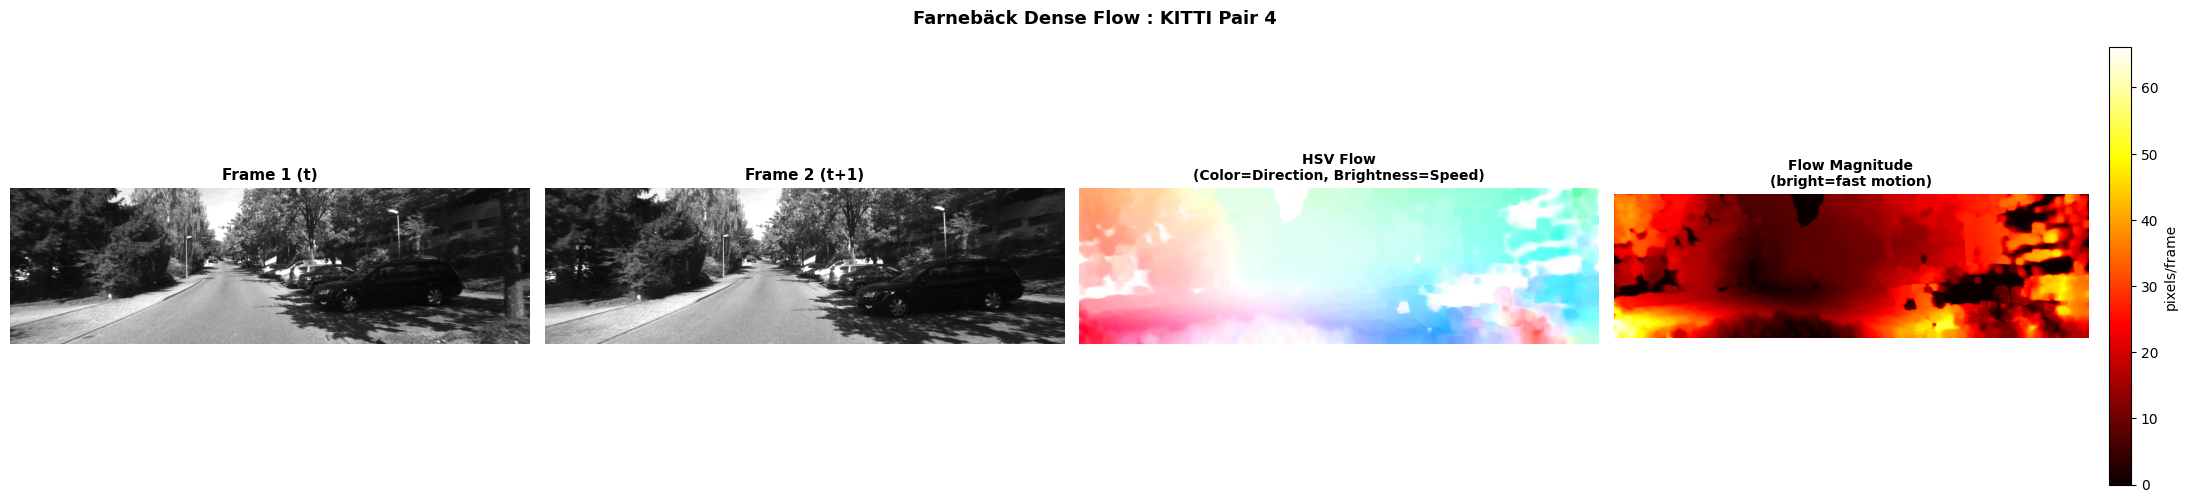

Mean magnitude: 17.435 px/frame

Pair 5/5: 000004_10.png
Flow shape: (376, 1241, 2)
u range: [-33.73, 86.17] pixels
v range: [-35.55, 89.99] pixels


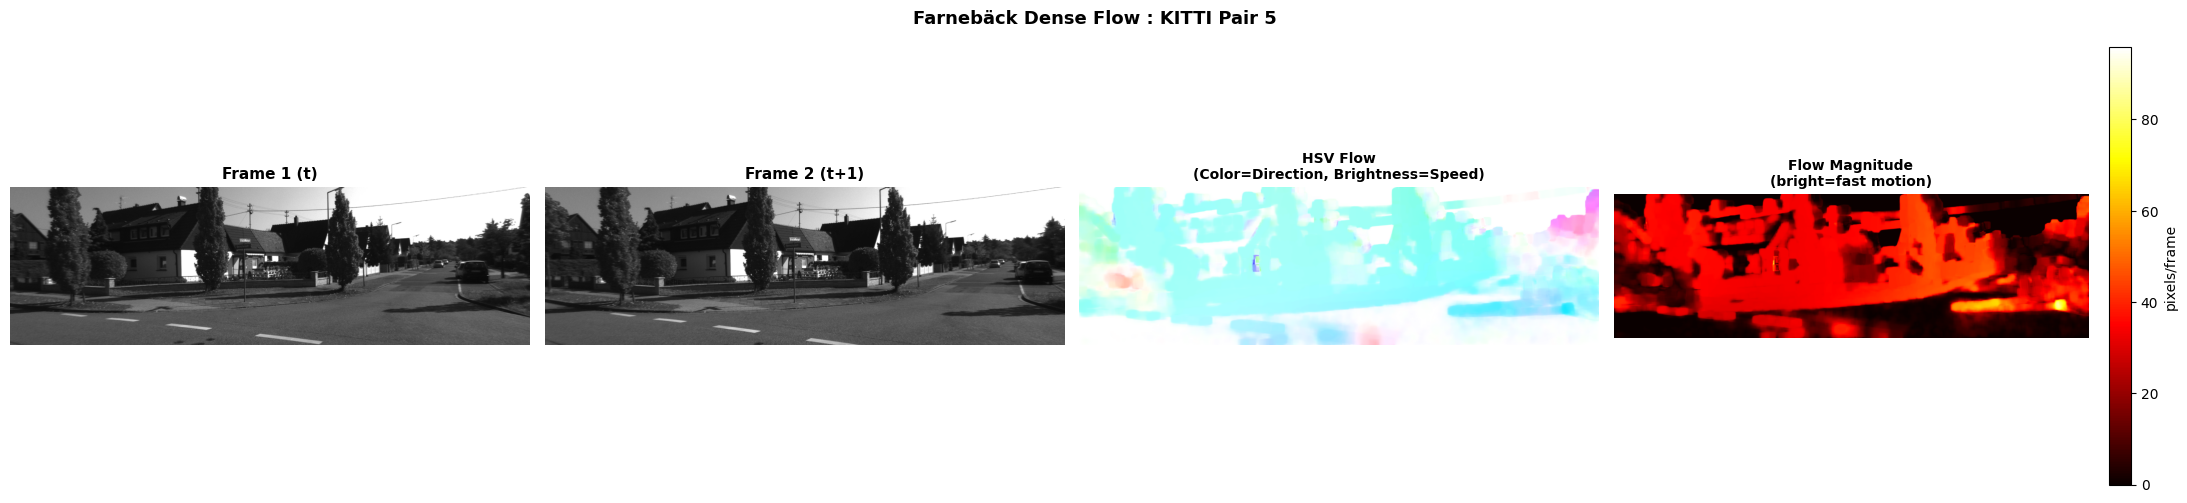

Mean magnitude: 21.445 px/frame

 Farnebäck complete


In [26]:
# RUN FARNEBÄCK ON KITTI

print("Running Farnebäck Dense Flow on KITTI dataset...")

fb_results = []  # Store results

for i, (f1_path, f2_path) in enumerate(pairs[:5]):
    print(f"\nPair {i+1}/5: {os.path.basename(f1_path)}")

    frame1 = load_image(f1_path)
    frame2 = load_image(f2_path)

    # Compute dense flow
    flow = compute_farneback(frame1, frame2)

    print(f"Flow shape: {flow.shape}")
    print(f"u range: [{flow[:,:,0].min():.2f}, {flow[:,:,0].max():.2f}] pixels")
    print(f"v range: [{flow[:,:,1].min():.2f}, {flow[:,:,1].max():.2f}] pixels")

    # Visualize
    fig, flow_hsv = visualize_farneback(
        frame1, frame2, flow,
        title=f"Farnebäck Dense Flow : KITTI Pair {i+1}"
    )

    # Save
    save_path = f"{OUTPUT_DIR}/farneback/pair_{i+1:02d}.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

    # Statistics
    magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
    result = {
        'pair_id': i + 1,
        'mean_magnitude': magnitude.mean(),
        'max_magnitude': magnitude.max(),
        'flow': flow,
        'flow_hsv': flow_hsv
    }
    fb_results.append(result)

    print(f"Mean magnitude: {result['mean_magnitude']:.3f} px/frame")

print("\n Farnebäck complete")

#Failure Case Analysis

Classical methods fail when:
1. **Large motion** : assumption of small displacement violated
2. **Texture-less regions** : no gradients to estimate flow
3. **Illumination changes** : brightness constancy assumption violated
4. **Occlusion** : a pixel visible in frame1 disappears in frame2

This section visualizes these failure modes.

Analyzing failure cases...
Detected 126 keypoints in frame 1
Successfully tracked 112/126 points


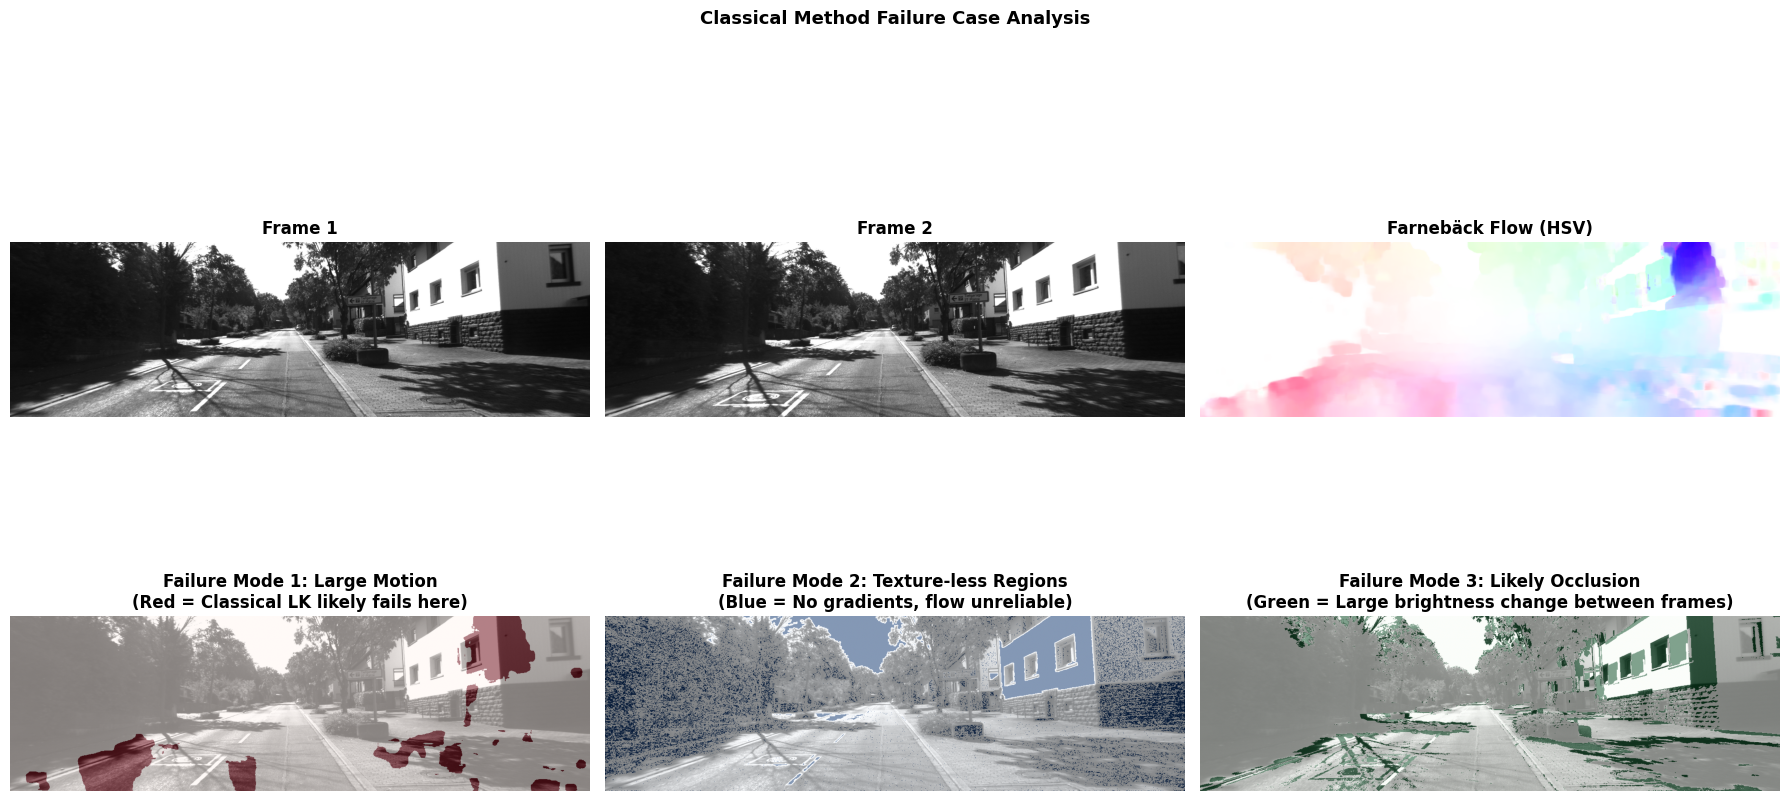

In [28]:
# FAILURE CASE ANALYSIS

def analyze_failure_cases(frame1, frame2, flow_fb, lk_old, lk_new):

    gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

    # Failure Mode 1: Large Motion Regions
    # Where magnitude > threshold, LK struggles
    magnitude = np.sqrt(flow_fb[:,:,0]**2 + flow_fb[:,:,1]**2)
    large_motion_mask = magnitude > np.percentile(magnitude, 90)  # Top 10% motion

    # Failure Mode 2: Texture-less Regions
    # Compute image gradient magnitude
    # Regions with very small gradients = texture-less = flow unreliable
    grad_x = cv2.Sobel(gray1, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray1, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    textureless_mask = gradient_magnitude < np.percentile(gradient_magnitude, 20)

    # Failure Mode 3: Occlusion
    # Where frame2 looks very different from frame1 = likely occlusion
    brightness_diff = np.abs(gray1.astype(float) - gray2.astype(float))
    occlusion_mask = brightness_diff > np.percentile(brightness_diff, 85)

    # VISUALIZATION
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1: Original frames and Farneback flow
    axes[0,0].imshow(frame1)
    axes[0,0].set_title("Frame 1", fontweight='bold')
    axes[0,0].axis('off')

    axes[0,1].imshow(frame2)
    axes[0,1].set_title("Frame 2", fontweight='bold')
    axes[0,1].axis('off')

    axes[0,2].imshow(flow_to_hsv(flow_fb))
    axes[0,2].set_title("Farnebäck Flow (HSV)", fontweight='bold')
    axes[0,2].axis('off')

    # Row 2: Failure modes
    axes[1,0].imshow(frame1)
    axes[1,0].imshow(large_motion_mask, alpha=0.5, cmap='Reds')
    axes[1,0].set_title("Failure Mode 1: Large Motion\n(Red = Classical LK likely fails here)",
                        fontweight='bold')
    axes[1,0].axis('off')

    axes[1,1].imshow(frame1)
    axes[1,1].imshow(textureless_mask, alpha=0.5, cmap='Blues')
    axes[1,1].set_title("Failure Mode 2: Texture-less Regions\n(Blue = No gradients, flow unreliable)",
                        fontweight='bold')
    axes[1,1].axis('off')

    axes[1,2].imshow(frame1)
    axes[1,2].imshow(occlusion_mask, alpha=0.5, cmap='Greens')
    axes[1,2].set_title("Failure Mode 3: Likely Occlusion\n(Green = Large brightness change between frames)",
                        fontweight='bold')
    axes[1,2].axis('off')

    plt.suptitle("Classical Method Failure Case Analysis\n",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    return fig


# Run failure analysis on first pair
if pairs and fb_results and lk_results:
    print("Analyzing failure cases...")

    frame1 = load_image(pairs[0][0])
    frame2 = load_image(pairs[0][1])

    # Get Farneback flow for pair 0
    flow_fb = compute_farneback(frame1, frame2)

    # Get LK points for pair 0
    _, _, good_old, good_new, _ = compute_lucas_kanade(frame1, frame2)

    fig = analyze_failure_cases(frame1, frame2, flow_fb, good_old, good_new)
    plt.savefig(f"{OUTPUT_DIR}/failure_cases_classical.png", bbox_inches='tight', dpi=150)
    plt.show()


Save a summary of classical flow results.
This will be loaded by Comparative Analysis Notebook  for the final comparison.

In [31]:
import json

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

summary = {
    'lucas_kanade': {
        'method': 'Lucas-Kanade (Sparse)',
        'type': 'Classical Sparse',
        'pairs_evaluated': len(lk_results),
        'mean_tracked_points': np.mean([r['n_tracked'] for r in lk_results]),
        'mean_motion_magnitude': np.mean([r['mean_motion'] for r in lk_results]),
        'advantages': [
            'Very fast (real-time capable)',
            'No training data required',
            'Mathematically interpretable',
            'Works well for small motion'
        ],
        'disadvantages': [
            'Only tracks sparse keypoints',
            'Fails on large motion (>~15 pixels)',
            'Fails on texture-less regions',
            'Assumes brightness constancy (fails with lighting changes)'
        ]
    },
    'farneback': {
        'method': 'Farnebäck (Dense)',
        'type': 'Classical Dense',
        'pairs_evaluated': len(fb_results),
        'mean_motion_magnitude': np.mean([r['mean_magnitude'] for r in fb_results]),
        'advantages': [
            'Dense flow : every pixel has a value',
            'No training data required',
            'Good for small-medium motion'
        ],
        'disadvantages': [
            'Slower than Lucas-Kanade',
            'Struggles with large displacements',
            'Polynomial assumption breaks on sharp boundaries'
        ]
    }
}

with open(f"{OUTPUT_DIR}/classical_results_summary.json", 'w') as f:
    json.dump(summary, f, indent=2, cls=NumpyEncoder)

print(f"Saved to: {OUTPUT_DIR}/classical_results_summary.json")

Saved to: /content/drive/MyDrive/OpticalFlow/results/classical_results_summary.json
